## Featuring engineering


In [1]:
import pandas as pd
df = pd.read_csv("loan_data.csv")
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [2]:
df["loan_to_income"] = df["loan_amnt"] / df["person_income"]

In [3]:
df[[
    "loan_amnt",
    "person_income",
    "loan_to_income"
]].head()

,loan_amnt,person_income,loan_to_income
0,35000.0,71948.0,0.486462
1,1000.0,12282.0,0.081420
2,5500.0,12438.0,0.442193
3,35000.0,79753.0,0.438855
4,35000.0,66135.0,0.529221


In [4]:
df[[
    "loan_amnt",
    "person_income",
    "loan_percent_income",
    "loan_to_income"
]].head()

,loan_amnt,person_income,loan_percent_income,loan_to_income
0,35000.0,71948.0,0.49,0.486462
1,1000.0,12282.0,0.08,0.081420
2,5500.0,12438.0,0.44,0.442193
3,35000.0,79753.0,0.44,0.438855
4,35000.0,66135.0,0.53,0.529221


In [5]:
difference = (
    df["loan_to_income"] - df["loan_percent_income"]
).abs()

print(difference.max())

0.00503013444598982


In [6]:
df = df.drop("loan_to_income", axis=1)

In [7]:
df["age_group"] = pd.cut(
    df["person_age"],
    bins=[17, 25, 35, 50, 100],
    labels=["Young", "Adult", "Middle", "Senior"]
)

In [9]:
df[["person_age","age_group"]].head()

,person_age,age_group
0,22.0,Young
1,21.0,Young
2,25.0,Young
3,23.0,Young
4,24.0,Young


In [10]:
df["age_group"].value_counts()

age_group
Young     20441
Adult     20073
Middle     4158
Senior      321
Name: count, dtype: int64

In [11]:
df["person_income"].describe()

count    4.500000e+04
mean     8.031905e+04
std      8.042250e+04
min      8.000000e+03
25%      4.720400e+04
50%      6.704800e+04
75%      9.578925e+04
max      7.200766e+06
Name: person_income, dtype: float64

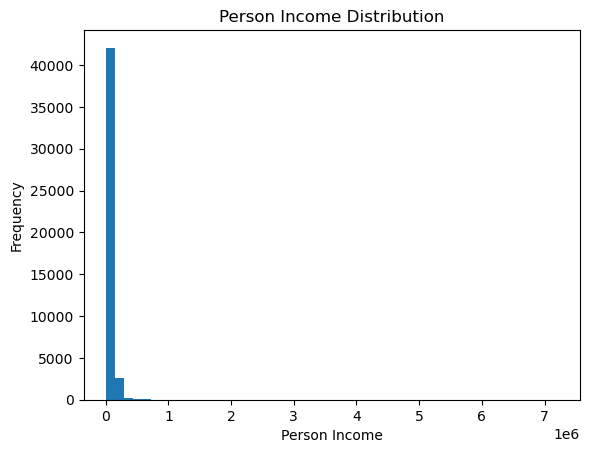

In [12]:
import matplotlib.pyplot as plt

plt.hist(df["person_income"], bins=50)
plt.xlabel("Person Income")
plt.ylabel("Frequency")
plt.title("Person Income Distribution")
plt.show()

In [14]:
import numpy as np

df["log_income"] = np.log1p(df["person_income"]) #burada log1p = log(1+x)

In [15]:
df[["person_income", "log_income"]].head()

,person_income,log_income
0,71948.0,11.183713
1,12282.0,9.415971
2,12438.0,9.428592
3,79753.0,11.286702
4,66135.0,11.099469


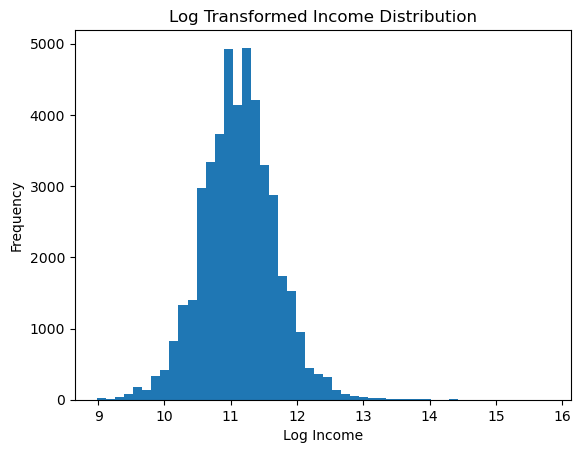

In [16]:
plt.hist(df["log_income"], bins=50)
plt.xlabel("Log Income")
plt.ylabel("Frequency")
plt.title("Log Transformed Income Distribution")
plt.show()

In [22]:
import pandas as pd

In [23]:
from sklearn.model_selection import GridSearchCV

In [26]:
X = df.drop("loan_status", axis=1)
y = df["loan_status"]

In [28]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [30]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42)

In [42]:
param_grid = {
    "classifier__max_depth": [5, 10, 15]
}

In [43]:
from sklearn.preprocessing import OneHotEncoder

categorical_features = [
    "person_gender",
    "person_education",
    "person_home_ownership",
    "loan_intent",
    "previous_loan_defaults_on_file"
]

numerical_features = [
    "person_age",
    "person_income",
    "person_emp_exp",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length",
    "credit_score"
]

In [44]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numerical_features)
    ]
)

In [45]:
from sklearn.pipeline import Pipeline

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

In [46]:
grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=5,
    scoring="accuracy"
)

In [47]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['person_gender',
                                                                          'person_education',
                                                                          'person_home_ownership',
                                                                          'loan_intent',
                                                                          'previous_loan_defaults_on_file']),
                                                                        ('num',
                                                                         'passthrough',
                                                                         ['person_age',
                                                                          'person_income',
                                                                          'person_emp_exp',
                                                                          'loan_amnt',
                                                                          'loan_int_rate',
                                                                          'loan_percent_income',
                                                                          'cb_person_cred_hist_length',
                                                                          'credit_score'])])),
                                       ('classifier',
                                        RandomForestClassifier(random_state=42))]),
             param_grid={'classifier__max_depth': [5, 10, 15]},
             scoring='accuracy')

In [50]:
grid_search.best_params_
grid_search.best_score_

0.9261944444444443

In [51]:
y_pred_grid = grid_search.predict(X_test)

In [52]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred_grid)

0.928

In [54]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_grid))

              precision    recall  f1-score   support

           0       0.93      0.98      0.95      7000
           1       0.91      0.75      0.82      2000

    accuracy                           0.93      9000
   macro avg       0.92      0.86      0.89      9000
weighted avg       0.93      0.93      0.93      9000

